In [1]:
import seaborn as sns
import pandas as pd
from pyspark.sql import Window
import pyspark.sql.functions as F
import matplotlib.pyplot as plt

In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("RetailRocket")
    .getOrCreate()
)

In [3]:
df_events = spark.read.csv(
    "../data/interim/events.csv",
    header=True,
    inferSchema=True
)

df_prop_1 = spark.read.csv(
    "../data/interim/item_properties_part1.csv",
    header=True,
    inferSchema=True
)

df_prop_2 = spark.read.csv(
    "../data/interim/item_properties_part2.csv",
    header=True,
    inferSchema=True
)
df_prop = df_prop_1.unionByName(df_prop_2)

In [13]:
window_spec = (
    Window
    .partitionBy("itemid", "property")
    .orderBy(F.col("timestamp").desc())
)

df_prop_last = (
    df_prop
    .withColumn("rn", F.row_number().over(window_spec))
    .filter(F.col("rn") == 1)
    .drop("rn")
)

df_items = (
    df_prop_last
    .filter(F.col("property").isin(["categoryid", "available"]))
    .groupBy("itemid")
    .pivot("property")
    .agg(F.first("value"))
)

df_eda = df_events.join(df_items, on="itemid", how="left")

# Baseline 1 - popularity

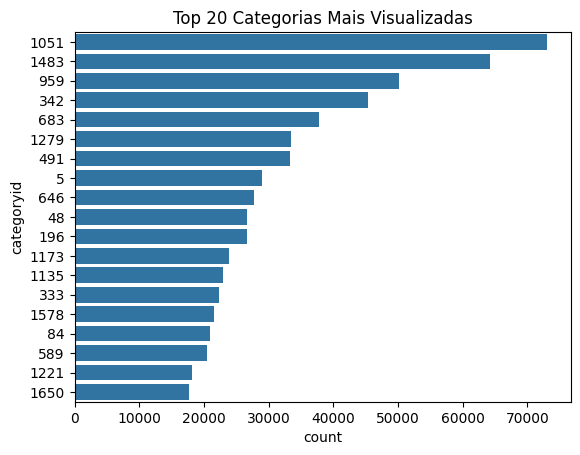

In [7]:
# Baseline 1 - popularity
views_categoria = (
    df_eda
    .filter("event='view'")
    .groupBy("categoryid")
    .count()
    .orderBy("count", ascending=False)
    .limit(20)
    .toPandas()
)

sns.barplot(
    data=views_categoria,
    y="categoryid",
    x="count"
)

plt.title("Top 20 Categorias Mais Visualizadas")
plt.show()

In [9]:
popularity = (
    df_eda
    .groupBy("itemid")
    .agg(
        F.sum(
            F.when(F.col("event") == "view", 1)
             .when(F.col("event") == "addtocart", 3)
             .when(F.col("event") == "transaction", 5)
             .otherwise(0)
        ).alias("score")
    )
    .orderBy("score", ascending=False)
)

# Top N itens — será a recomendação para qualquer usuário
top_n_items = popularity.limit(10).toPandas()
print(top_n_items)

   itemid  score
0  461686   4122
1  187946   3416
2    5411   2352
3  219512   1944
4  257040   1933
5  320130   1921
6    7943   1867
7  370653   1854
8  384302   1798
9  309778   1784


# Baseline 2 - Modelo de KNN

In [ ]:
WEIGHTS = {"view": 1, "addtocart": 3, "transaction": 5}

interacoes = (
    df_eda
    .withColumn(
        "peso",
        F.when(F.col("event") == "view", F.lit(1))
         .when(F.col("event") == "addtocart", F.lit(3))
         .when(F.col("event") == "transaction", F.lit(5))
         .otherwise(F.lit(0)),
    )
    .groupBy("visitorid", "itemid")
    .agg(F.sum("peso").alias("peso"))
)

interacoes.show(10)

+---------+------+----+
|visitorid|itemid|peso|
+---------+------+----+
|   623748|305760|   1|
|   820159|281211|   1|
|  1312385|337358|   1|
|  1154250|367790|   6|
|   260791|323381|   1|
|   302896|257196|   2|
|   649450| 19664|   1|
|   322407|277275|   4|
|  1305172|446534|   1|
|  1293117|405481|   1|
+---------+------+----+
only showing top 10 rows



In [ ]:
# Contar interações por usuário
contagem_usuarios = (
    interacoes
    .groupBy("visitorid")
    .agg(F.count("itemid").alias("n_itens"))
)

# Manter só usuários com >= 5 itens distintos
usuarios_ativos = (
    contagem_usuarios
    .filter(F.col("n_itens") >= 5)
    .select("visitorid")
)

interacoes_filtradas = interacoes.join(usuarios_ativos, on="visitorid", how="inner")

total_usuarios = interacoes.select("visitorid").distinct().count()
usuarios_mantidos = usuarios_ativos.count()

print(f"Usuários totais:   {total_usuarios:>8,}")
print(f"Usuários ativos:   {usuarios_mantidos:>8,}")
print(f"Descartados:       {total_usuarios - usuarios_mantidos:>8,} "
      f"({(1 - usuarios_mantidos/total_usuarios)*100:.1f}%)")

Usuários totais:   1,407,580
Usuários ativos:     39,635
Descartados:       1,367,945 (97.2%)


In [18]:
# Ordenar por timestamp e separar últimas interações como ground truth
df_com_ts = (
    df_events
    .withColumn(
        "peso",
        F.when(F.col("event") == "view", F.lit(1))
         .when(F.col("event") == "addtocart", F.lit(3))
         .when(F.col("event") == "transaction", F.lit(5))
         .otherwise(F.lit(0)),
    )
    .join(usuarios_ativos, on="visitorid", how="inner")
    .orderBy("timestamp")
)

# 80% mais antigos → treino | 20% mais recentes → teste
total_linhas = df_com_ts.count()
split_idx = int(total_linhas * 0.8)

df_treino_spark = df_com_ts.limit(split_idx)
df_teste_spark  = df_com_ts.filter(
    F.col("timestamp") > df_com_ts.limit(split_idx)
                                   .agg(F.max("timestamp"))
                                   .collect()[0][0]
)

# Agregar treino por usuário-item
interacoes_treino = (
    df_treino_spark
    .groupBy("visitorid", "itemid")
    .agg(F.sum("peso").alias("peso"))
)

# Ground truth: itens que o usuário consumiu no período de teste
ground_truth = (
    df_teste_spark
    .groupBy("visitorid")
    .agg(F.collect_set("itemid").alias("itens_relevantes"))
)

print(f"Eventos treino: {df_treino_spark.count():,}")
print(f"Eventos teste:  {df_teste_spark.count():,}")

Eventos treino: 524,663
Eventos teste:  131,166


In [ ]:
# Trazer treino para o driver
df_pd = interacoes_treino.toPandas()
gt_pd = ground_truth.toPandas()

# Mapear IDs para índices contíguos 0..N-1
unique_users = df_pd["visitorid"].unique()
unique_items = df_pd["itemid"].unique()

user_to_idx = {u: i for i, u in enumerate(unique_users)}
item_to_idx = {it: i for i, it in enumerate(unique_items)}
idx_to_item = {i: it for it, i in item_to_idx.items()}
idx_to_user = {i: u for u, i in user_to_idx.items()}

# Construir csr_matrix
rows = df_pd["visitorid"].map(user_to_idx)
cols = df_pd["itemid"].map(item_to_idx)
data = df_pd["peso"].astype(float)

matrix = csr_matrix(
    (data, (rows, cols)),
    shape=(len(unique_users), len(unique_items)),
)

print(f"Matriz: {matrix.shape}")
print(f"Densidade: {matrix.nnz / (matrix.shape[0] * matrix.shape[1]) * 100:.4f}%")
print(f"Memória (sparse): {matrix.data.nbytes / 1e6:.1f} MB")   

In [ ]:
def recomendar_knn(
    user_idx: int,
    matrix: csr_matrix,
    knn_model: NearestNeighbors,
    idx_to_item: dict,
    n: int = N_RECS,
) -> list[int]:
    """Retorna os n itens recomendados para um usuário pelo índice."""
    distances, neighbors = knn_model.kneighbors(matrix[user_idx])

    # Remove o próprio usuário (sempre distância 0, sempre posição 0)
    neighbor_idxs  = neighbors[0][1:]
    similarities   = 1 - distances[0][1:]   # cosseno: distância → similaridade

    # Soma ponderada: cada vizinho contribui com seus itens × sua similaridade
    neighbor_matrix = matrix[neighbor_idxs].toarray()  # (K, n_items)
    scores = similarities @ neighbor_matrix             # (n_items,)

    # Zerar itens que o usuário já viu
    ja_viu = matrix[user_idx].nonzero()[1]
    scores[ja_viu] = -np.inf

    top_idxs = np.argsort(scores)[::-1][:n]
    return [idx_to_item[i] for i in top_idxs]


In [ ]:
# # Teste rápido com 1 usuário
# exemplo = recomendar_knn(0, matrix, knn, idx_to_item)
# print(f"Recomendações para usuário 0: {exemplo}")

In [ ]:
K_NEIGHBORS = 20
N_RECS = 10

knn = NearestNeighbors(
    metric="cosine",
    algorithm="brute",   # único compatível com cosine + sparse
    n_neighbors=K_NEIGHBORS + 1,  # +1 porque o próprio usuário aparece
    n_jobs=-1,           # usa todos os cores disponíveis
)

knn.fit(matrix)
print("KNN treinado.")

# Baseline 3 - SVD

In [12]:
from sklearn.decomposition import TruncatedSVD
import numpy as np

svd = TruncatedSVD(n_components=50, random_state=42)
user_factors = svd.fit_transform(matrix)       # (n_users, 50)
item_factors = svd.components_.T               # (n_items, 50)

# Score de um usuário com todos os itens = produto interno
def recomendar_svd(user_idx_val: int, n: int = 10) -> list:
    scores = user_factors[user_idx_val] @ item_factors.T
    ja_viu = matrix[user_idx_val].nonzero()[1]
    scores[ja_viu] = -np.inf
    return np.argsort(scores)[::-1][:n].tolist()

In [ ]:
def precision_at_k(recomendados: list, relevantes: set, k: int) -> float:
    hits = len(set(recomendados[:k]) & relevantes)
    return hits / k

def recall_at_k(recomendados: list, relevantes: set, k: int) -> float:
    if not relevantes:
        return 0.0
    hits = len(set(recomendados[:k]) & relevantes)
    return hits / len(relevantes)

def ndcg_at_k(recomendados: list, relevantes: set, k: int) -> float:
    dcg = sum(
        1 / np.log2(rank + 2)
        for rank, item in enumerate(recomendados[:k])
        if item in relevantes
    )
    ideal = sum(1 / np.log2(i + 2) for i in range(min(len(relevantes), k)))
    return dcg / ideal if ideal > 0 else 0.0

def coverage(todas_recs: list[list], n_itens_total: int) -> float:
    unicos = {item for recs in todas_recs for item in recs}
    return len(unicos) / n_itens_total